# Исследование заведений общественного питания в Москве

Автор: Артур Карапетян

Дата: 02.04.2026
## Цель и задачи  

**Цель:** Провести исследовательский анализ данных заведений общественного питания в Москве для постороения стратегии открытия и развития бизнеса в сфере общепита.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных.
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа будем использовать датасеты с заведениями общественного питания Москвы, составленные на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках. Она носит исключительно справочный характер. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное `0` или `1`, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.

### Описание датасета `rest_price`

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
    и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


## Структура проекта

1. [Загрузка данных и знакомство с ними.](#link1)
2. [Предобработка данных.](#link2)
3. [Исследовательский анализ данных.](#link3)
4. [Итоговые выводы.](#link4)

---

<a class='anchor' id="link1"></a>
## 1. Загрузка данных

Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать `pandas` и библиотеки визуализации данных `matplotlib` и `seaborn`, а также `phik` для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
# Устанавливаем библиотеку phik
!pip install phik -U    
# Библиотека для расчета коэффициента корреляции phi_k
#from phik import phik_matrix

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()` и информацию методом `info()`

In [4]:
# Выводим первые строки датафрейма на экран
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


После первичного анализа данных можно сделать следующие выводы:
 - Датасет содержит 9 столбцов и 8406 строк;
 - Названия столбцов соответствуют данным в них;
 - Названия столбцов не требуют преобразования;
 - Столбец `seats` имеет тип данных `float64` и содержит целочисленные значения. Тип данных в этом столбце необходимо преобразовать. В остальных столбцах тип данных не требует преобразования;
 - В столбцах `hours` и `seats` содержатся пропуски
 - В столбце `chain`, содержащем информацию о том является ли заведение сетевым, для маленьких сетей могут встречаться ошибки. Этот столбец имеет тип данных `int64` и его размерность можно оптимизировать.

Познакомимся с данными датасета `rest_price.csv`

In [6]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


По аналогии с предыдущим датасетом можно отметить:
 - Датасет содержит 5 столбцов и 4058 строк;
 - Название столбца `price` следует переименовать в `price_category`, так как в этом столбце хранится информация о ценовой категории. Названия остальных столбцов соответствуют данным в них;
 - Типы данных во всех столбцах не требуют преобразования;
 - Во всех столбцах, кроме `id`, содержатся пропуски.
 - Пропуски в столбцах `middle_avg_bill` и `middle_coffee_cup` зависят от значений в столбце `avg_bill`:
    - Если в столбце `avg_bill` значение начинается словами `Средний счёт` значит в столбце `middle_coffee_cup` будет пропуск;
    - Если в столбце `avg_bill` значение начинается словами `Цена чашки капучино` значит в столбце `middle_avg_bill` будет пропуск.

Первичное знакомство показывает, что данные хорошего качества — они соответствуют описанию и выглядят корректными. Однако, имеется большое количество пропущенных значений в датасете `rest_price.csv`.

#### Соединяем данные в единый датафрейм

Соединим данные, используя значение `left` для параметра `how`. Так к датафрейму `info_df` мы присоединим датафрейм `price_df`, используя `id` в качестве ключа.

In [8]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, how='left', on='id')

In [9]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


<a class='anchor' id="link2"></a>
## 2. Предобработка данных
При проведении предобработки данных вначале скорректируем названия столбцов, затем проверим типы данных и пропуски.

#### Меняем названия, или метки, столбцов датафрейма

Проверим названия столбцов

In [10]:
# Выводим названия столбцов
df.columns

Index(['id', 'name', 'category', 'address', 'district', 'hours', 'rating',
       'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill',
       'middle_coffee_cup'],
      dtype='object')

Названия столбцов соответствуют данным и не требуют изменений.

#### Оптимизируем типы данных
Оптимизируем размерность столбца `chain`.

In [11]:
# Оптимизируем размерность столбца chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [12]:
# Оптимизируем размерность столбцов формата float
for column in ['rating','middle_avg_bill','middle_coffee_cup','seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

#### Проверяем наличие пропусков в данных
При первичном анализе мы обнаружили пропуски в столбцах `hours` и `seats`. Узнаем абсолютное и относительное количество пропусков.

In [13]:
# Напишем функцию для обнаружения пропусков
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


Столбец `hours` содержит 536 пропущенных значений - это 6% данных. Столбец `seats` содержит 3611 пропусков, что составляет 43% данных. Чтобы избежать искажения в сатистических показателях оставим пропуски как есть. Эти пропуски мы проигнорируем.
Столбец `price` содержит 5091 пропуска или 61% данных. Столбец `avg_bill` содержит 4590 пропуска или 55% данных. Столбец `middle_avg_bill` содержит 5257 пропусков или 63% данных. Столбец `middle_coffee_cup` содержит 7871 пропуска или 94% данных. В связи с контекстом данных (пропуски в `middle_avg_bill` и `middle_coffee_cup` зависят от значений в `avg_bill`) на данном этапе оставим пропуски как есть, чтобы не допустить искажения в будущих расчетах. Посмотрим на уникальные значения в этих столбцах.

Наличие пропусков возможно по причине того, что датасет составлен на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года и информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках.

In [14]:
# Проверяем уникальные значения
for column in ['price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup', 'category', 'district']:
    print(f'Уникальные значения столбца {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения столбца price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]

Уникальные значения столбца avg_bill:
['Средний счёт:100 ₽' 'Средний счёт:1000 ₽' 'Средний счёт:1000–10000 ₽'
 'Средний счёт:1000–1100 ₽' 'Средний счёт:1000–1200 ₽'
 'Средний счёт:1000–1300 ₽' 'Средний счёт:1000–1350 ₽'
 'Средний счёт:1000–1400 ₽' 'Средний счёт:1000–1500 ₽'
 'Средний счёт:1000–1600 ₽' 'Средний счёт:1000–1700 ₽'
 'Средний счёт:1000–2000 ₽' 'Средний счёт:1000–2500 ₽'
 'Средний счёт:1000–3000 ₽' 'Средний счёт:1000–5000 ₽'
 'Средний счёт:100–1000 ₽' 'Средний счёт:100–160 ₽'
 'Средний счёт:100–180 ₽' 'Средний счёт:100–200 ₽'
 'Средний счёт:100–2000 ₽' 'Средний счёт:100–270 ₽'
 'Средний счёт:100–300 ₽' 'Средний счёт:100–330 ₽'
 'Средний счёт:100–350 ₽' 'Средний счёт:100–400 ₽'
 'Средний счёт:100–423 ₽' 'Средний счёт:100–500 ₽'
 'Средний счёт:100–599 ₽' 'Средний счёт:100–700 ₽'
 'Средний счёт:1100–1500 ₽' 'Средний счёт:110–200 ₽' 'Средний счёт:120 ₽'
 'Средний счёт:1200 ₽' 'Средний счёт:120

В значениях ценовых категорий, категорий заведений и округов неявных дубликатов и прочих ошибок нет.

#### Явные и неявные дубликаты в данных
Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [15]:
# Проверяем полные дубликаты
df.duplicated().sum()

0

В датафрейме нет полных дубликатов строк. Продолжим проверку на неявные дубликаты — значения по id заведений должны быть уникальными, то есть каждая строка в данных — уникальное заведение:

In [16]:
# Проверяем неявные дубликаты в датафрейме info_df
df.duplicated(subset='id').sum()

0

Столбцы `name` и `address` содержат уникальные значения и могут содержать неявные дубликаты. Чтобы их выявить предварительно в копии датафрейма приведем значения этих столбцов к нижнему регистру и удалим конечные пробелы.

In [17]:
# Создаем копию датафрейма, чтобы не испортить исходные данные
df_clean = df.copy()

# Приводим name и address к нижнему регистру и удаляем пробелы по краям
for i in range(len(df_clean)):
    # Проверяю, что значение не пустое
    if pd.notna(df_clean.loc[i, 'name']):
        # Привожу к строке, убираю пробелы, делаю нижний регистр
        df_clean.loc[i, 'name'] = str(df_clean.loc[i, 'name']).strip().lower()
    
    if pd.notna(df_clean.loc[i, 'address']):
        df_clean.loc[i, 'address'] = str(df_clean.loc[i, 'address']).strip().lower()

# Создаем временный столбец с объединенными данными
df_clean['name_address'] = df_clean['name'] + ' | ' + df_clean['address']

# Находим дубликаты
# Создаем маску для дубликатов
duplicate_mask = df_clean.duplicated(subset=['name_address'], keep=False)

# Выделяем дубликаты в отдельный датафрейм
duplicates = df_clean[duplicate_mask].copy()

# Выводим статистику
print("=" * 50)
print("ОТЧЕТ ПО НЕЯВНЫМ ДУБЛИКАТАМ")
print("=" * 50)
print(f"Всего записей в данных: {len(df)}")
print(f"Найдено записей-дубликатов: {len(duplicates)}")
print(f"Количество уникальных дублирующихся пар: {duplicates['name_address'].nunique()}")
print("=" * 50)

# Показываем примеры дубликатов
if len(duplicates) > 0:
    print("\nПРИМЕРЫ НАЙДЕННЫХ ДУБЛИКАТОВ:")
    print("-" * 50)
    
    # Группируем дубликаты для наглядности
    grouped = duplicates.groupby('name_address')
    
    # Показываем первые 5 групп дубликатов
    for i, (key, group) in enumerate(grouped):
        if i >= 5:
            break
        print(f"\nГруппа дубликатов #{i+1}:")
        print(f"  Объединенный ключ: '{key}'")
        print(f"  Количество повторений: {len(group)}")
        print("  Оригинальные записи:")
        for idx, row in group.iterrows():
            print(f"    - name: {df.loc[idx, 'name']} | address: {df.loc[idx, 'address']}")

# Удаляем дубликаты
# Оставляем только первую запись из каждой группы дубликатов
df_final = df_clean.drop_duplicates(subset=['name_address'], keep='first').copy()

# Удаляем временный столбец
df_final = df_final.drop(columns=['name_address'])

print("\n" + "=" * 50)
print("ИТОГИ ОБРАБОТКИ:")
print("=" * 50)
print(f"Было записей: {len(df)}")
print(f"Стало записей: {len(df_final)}")
print(f"Удалено дубликатов: {len(df) - len(df_final)}")
print(f"Процент потерь: {round(((len(df) - len(df_final))/len(df)*100), 2)}")
print("=" * 50)

ОТЧЕТ ПО НЕЯВНЫМ ДУБЛИКАТАМ
Всего записей в данных: 8406
Найдено записей-дубликатов: 8
Количество уникальных дублирующихся пар: 4

ПРИМЕРЫ НАЙДЕННЫХ ДУБЛИКАТОВ:
--------------------------------------------------

Группа дубликатов #1:
  Объединенный ключ: 'more poke | москва, волоколамское шоссе, 11, стр. 2'
  Количество повторений: 2
  Оригинальные записи:
    - name: More poke | address: Москва, Волоколамское шоссе, 11, стр. 2
    - name: More Poke | address: Москва, Волоколамское шоссе, 11, стр. 2

Группа дубликатов #2:
  Объединенный ключ: 'кафе | москва, парк ангарские пруды'
  Количество повторений: 2
  Оригинальные записи:
    - name: Кафе | address: Москва, парк Ангарские Пруды
    - name: Кафе | address: Москва, парк Ангарские пруды

Группа дубликатов #3:
  Объединенный ключ: 'раковарня клешни и хвосты | москва, проспект мира, 118'
  Количество повторений: 2
  Оригинальные записи:
    - name: Раковарня Клешни и Хвосты | address: Москва, проспект Мира, 118
    - name: Раковарня

Создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7. Для этого проверим какие значения встречаются в столбце `hours`

In [18]:
# Проверим уникальные значения hours
df_final['is_24_7'] = df_final['hours'].str.contains('ежедневно, круглосуточно', na=False)
print(df_final['is_24_7'].value_counts())
print(df_final[df_final['is_24_7'] == True][['name', 'hours']].head(10))

False    7672
True      730
Name: is_24_7, dtype: int64
                  name                     hours
10      great room bar  ежедневно, круглосуточно
17  чайхана беш-бармак  ежедневно, круглосуточно
19             пекарня  ежедневно, круглосуточно
24          drive café  ежедневно, круглосуточно
49             2u-ту-ю  ежедневно, круглосуточно
50              шаурма  ежедневно, круглосуточно
54              шашлык  ежедневно, круглосуточно
61           кафе лоза  ежедневно, круглосуточно
70           гуава бар  ежедневно, круглосуточно
84    meat doner kebab  ежедневно, круглосуточно


In [19]:
# Проверим правильность категоризации
tmp0, col1 = df_final.copy(), 'is_24_7'
a1 = len(tmp0[tmp0.hours != 'ежедневно, круглосуточно'])
a2 = len(tmp0[tmp0.hours == 'ежедневно, круглосуточно'])

print(" Количество не работающих ежедневно и круглосуточно", a1,
      '\n', "Количество работающих ежедневно и круглосуточно", a2,'\n')
print("Количество категорий полученное в проекте:")
try:
    print(tmp0[col1].value_counts())
except:
    print("Не создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения.")

 Количество не работающих ежедневно и круглосуточно 7672 
 Количество работающих ежедневно и круглосуточно 730 

Количество категорий полученное в проекте:
False    7672
True      730
Name: is_24_7, dtype: int64


#### Промежуточные выводы после предобработки
Предоставленные данные хорошего качества и требуют не так много действий по предобработке. 
В результате предобработки данных были выполнены следующие действия:
1. Объединены атафреймы `info_df` и `price_df`. Объединенный датасет содержал 8406 строк и 13 столбцов. После преобразований датасет`df_final` содержит 8402 и 14 столбцов. Датасет содержит данные о заведениях общепита Москвы. Датасет составлен на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках.
2. Типы данных в датафрейме не требовали изменений. В столбцах с числовыми типами данных `rating`,`middle_avg_bill`,`middle_coffee_cup`,`seats` и `chain` была понижена разрядность
3. Изучены пропуски в данных. 
    - Столбец `hours` - 536 пропусков - 6% данных.
    - Столбец `seats` - 3611 пропусков - 43% данных. 
    - Столбец `price` - 743 пропуска - 18% данных
    - Столбец `avg_bill` - 242 пропуска - 6% данных.
    - Столбец `middle_avg_bill` - 909 пропусков - 22% данных.
    - Столбец `middle_coffee_cup` - 3523 пропуска - 87% данных.
    
    Учитывая, что данные могли быть добавлены пользователями или найдены в общедоступных источниках, они носят исключительно справочный характер, пропуски оставили без изменений.
4. Датасет не содержит явных дубликатов. Удалено 4 неявных дубликата содержащих дублирующие значения `name` и `address`.
5. В датасет добавлен столбец `is_24_7`, который содержит бинарный признак является ли график работы заведения ежедневным и круглосуточным.
6. В итоговом виде датафрейм `df_final` содержит 8402 и 14 столбцов и готов к дальнейшему анализу.

In [20]:
# Комментарий ревьюера
# Проверим правильность категоризации
tmp0, col1 = df.copy(), 'is_24_7'
a1 = len(tmp0[tmp0.hours != 'ежедневно, круглосуточно'])
a2 = len(tmp0[tmp0.hours == 'ежедневно, круглосуточно'])

print(" Количество не работающих ежедневно и круглосуточно", a1,
      '\n', "Количество работающих ежедневно и круглосуточно", a2,'\n')
print("Количество категорий полученное в проекте:")
try:
    print(tmp0[col1].value_counts())
except:
    print("Не создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения.")

 Количество не работающих ежедневно и круглосуточно 7676 
 Количество работающих ежедневно и круглосуточно 730 

Количество категорий полученное в проекте:
Не создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения.


<a class='anchor' id="link3"></a>
## 3. Исследовательский анализ данных

#### Анализ категорий заведений
Узнаем количество заведений по каждой категории

In [21]:
# Выводим количество заведений в каждой категории
print('Количество заведений в категориях:\n', df_final['category'].value_counts())
print('\nКоличество заведений в категориях в относительных значениях:\n', df_final['category'].value_counts(normalize=True))

Количество заведений в категориях:
 кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

Количество заведений в категориях в относительных значениях:
 кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64


Самыми популярными категориями являются кафе, ресторан и кофейня. Представим распределение заведений по категориям в виде столбчатой диаграммы.

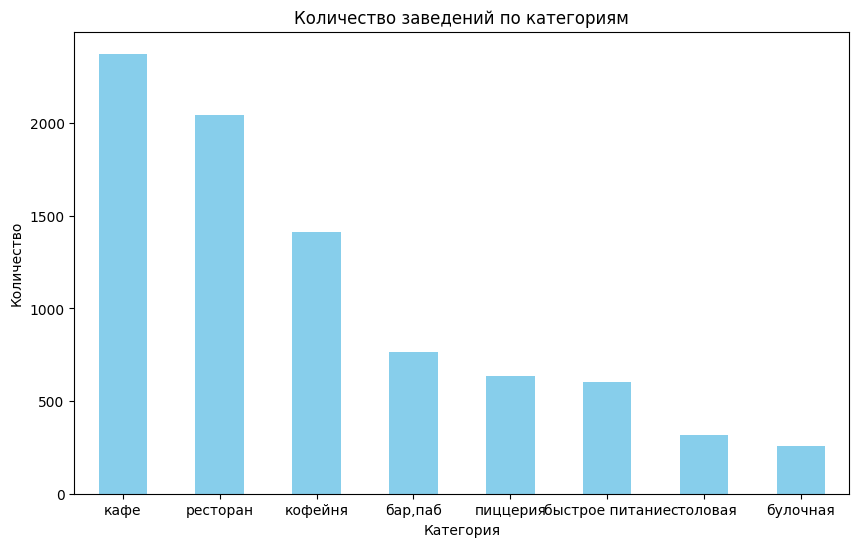

In [22]:
# Построим столбчатую диаграмму для визуализации распределения заведений по категориям
plt.figure(figsize=(10, 6))
df_final['category'].value_counts().plot(kind='bar',
                                         title='Количество заведений по категориям',
                                         legend=False,
                                         xlabel='Категория',
                                         ylabel='Количество',
                                         rot=0,
                                         color='skyblue')
plt.show()

На диаграмме визуально представлено распределение заведений по категориям. Видим, что категории кафе, ресторан и кофейня являются лидерами по количеству. Для запуска нового заведения стоит рассмотреть эти категории общепита.

#### Анализ административных районов Москвы

Узнаем как распределяются заведения по административным районам Москвы

In [23]:
# Выводим количество заведений в каждом административном районе
print('Количество заведений в категориях:\n', df_final['district'].value_counts())
print('\nКоличество заведений в категориях в относительных значениях:\n', df_final['district'].value_counts(normalize=True))

Количество заведений в категориях:
 Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Количество заведений в категориях в относительных значениях:
 Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный админист

Центральный административный округ - лидер по количеству заведений. Построим линейчатаю диаграмму для наглядного сравнения районов.

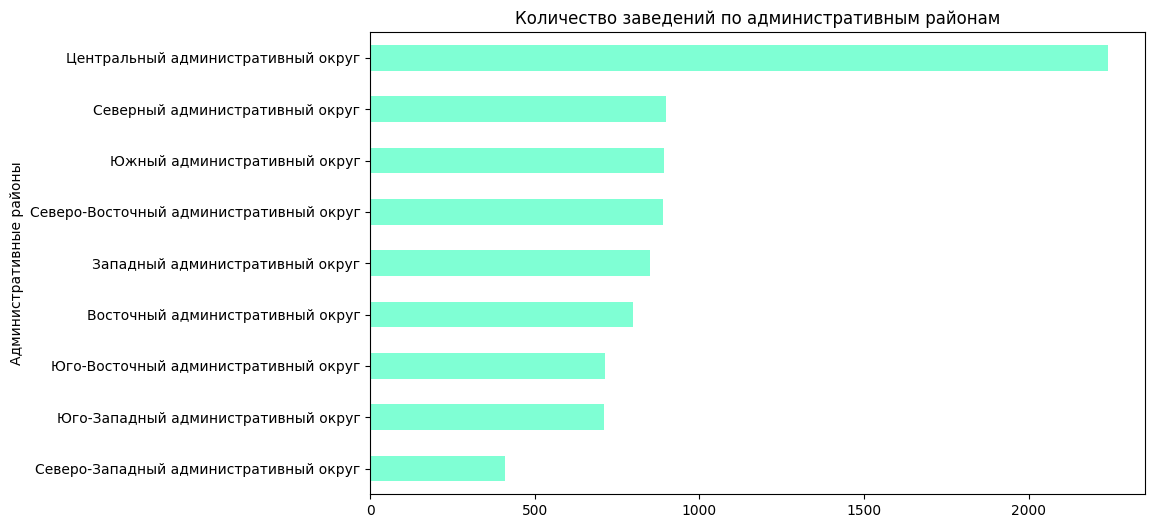

In [24]:
# Построим линейчатаю диаграмму для визуализации распределения заведений по административным районам
plt.figure(figsize=(10, 6))
df_final['district'].value_counts().sort_values().plot(kind='barh',
                                         legend=False,
                                         title='Количество заведений по административным районам',
                                         xlabel='Административные районы',
                                         ylabel='Количество',
                                         rot=0,
                                         color='aquamarine')
plt.show()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что для визуализации используем горизонтальную столбчатую диаграмму.</font>

Диаграмма наглядно показывает с каким отрывом Центральный административный округ лидирует по количеству заведений. Изучим этот район Москвы подробнее узнаем как внутри него заведения распределяются по категориям.

In [25]:
# Создаём датафрейм, в котором будет только интересующий нас административный округ
df_cao = df_final[df_final['district'] == 'Центральный административный округ']

# Выведем серию, в которой будет показано количество заведений округа по категориям
print('Количество заведений в категориях:\n', df_cao['category'].value_counts())
print('\nКоличество заведений в категориях в относительных значениях:\n', df_cao['category'].value_counts(normalize=True))

Количество заведений в категориях:
 ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

Количество заведений в категориях в относительных значениях:
 ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64


Построим отдельную диаграмму, в которой будет показано распределение заведений в центральном административном округе по категориям

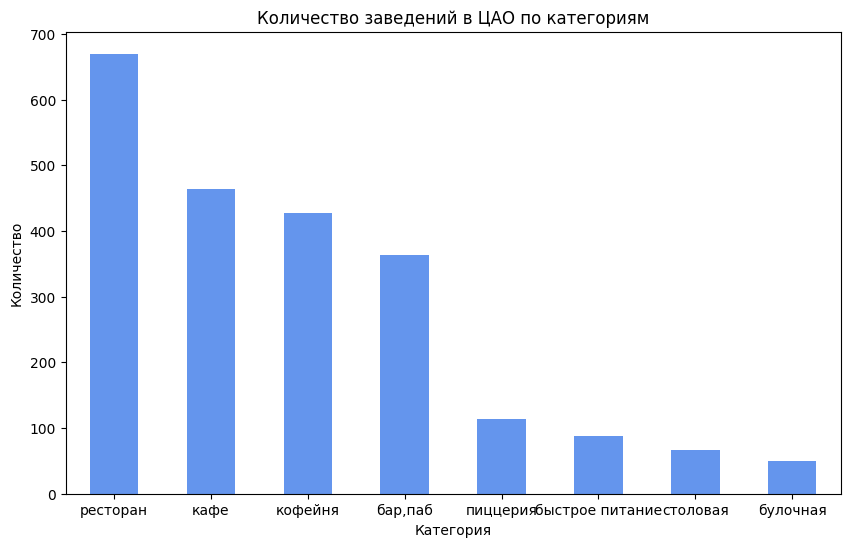

In [26]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим диаграмму
df_cao['category'].value_counts().plot(kind='bar',
                                       title='Количество заведений в ЦАО по категориям',
                                       xlabel='Категория',
                                       ylabel='Количество',
                                       rot=0,
                                       color='cornflowerblue')
plt.show()

Здесь мы видим, что картина отличается от общего распределения по всей Москве. Категория "ресторан" находится на первом месте по количеству заведений в центральном административном округе.

Чтобы избежать высокой конкуренции при выборе Центрального административного округа стоит рассмтореть категории кафе, кофейня или бар.

#### Анализ соотношения сетевых и несетевых заведений

Для бинарных признаков важно оценить, как распределяются заведения между признаками. При исследовании таких данных можно использовать метод `value_counts()` с аргументом `normalize=True`, чтобы сравнить доли значений. Узнаем долю сетевых и несетевых заведений.

In [27]:
# Выведем доли сетевых и несетевых заведений
print('\nКоличество заведений в категориях:\n', df_final['chain'].value_counts().reset_index())
print('\nКоличество заведений в категориях в относительных значениях:\n', round(df_final['chain'].value_counts(normalize=True), 2).reset_index())


Количество заведений в категориях:
    index  chain
0      0   5199
1      1   3203

Количество заведений в категориях в относительных значениях:
    index  chain
0      0   0.62
1      1   0.38


Чтобы наглядно увидеть разницу долей построим столбчатую диаграмму.

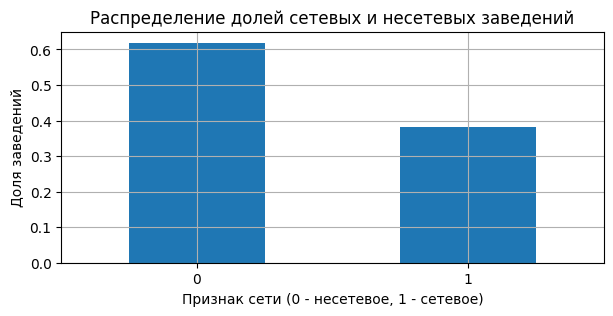

In [28]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму
df_final['chain'].value_counts(normalize=True).plot(kind='bar',
                                                    legend=False,
                                                    title='Распределение долей сетевых и несетевых заведений',
                                                    xlabel='Признак сети (0 - несетевое, 1 - сетевое)',
                                                    ylabel='Доля заведений',
                                                    rot=0,
                                                    grid=True)
plt.show()

На диаграмме видно, что доля несетевых заведений больше 60%. Теперь посмотрим на распределение долей сетевых заведений внутри категорий. Для этого построим столбчатую диаграмму.

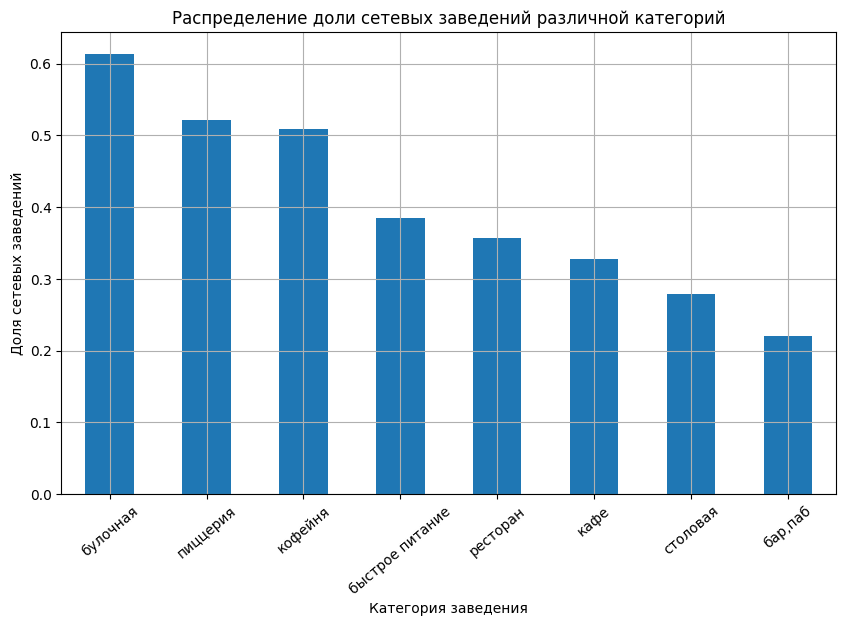

In [29]:
# Создаём датафрейм, в котором строки - значения category, а столбцы - значения chain
df_grouped = df_final.groupby('category')['chain'].mean().sort_values(ascending=False).head(8)

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим линейчатаю диаграмму
df_grouped.plot(kind='bar', title='Распределение доли сетевых заведений различной категорий',
                xlabel='Категория заведения',
                ylabel='Доля сетевых заведений',
                rot=40,
                grid=True)
plt.show()

Диаграмма показывает, что доля сетевых заведений преобладает в категориях "пиццерия", "кофейня" и "булочная". В остальных категориях преобладают несетевые заведения.

Стоит изучить конкурентов в категориях с высокой долей сетевых заведений.

#### Анализ заведений по количеству посадочных мест

Исследуем значения столбца `seats`, которое содержит количество посадочных мест в заведении. Посмотрим на статистические показатели с помощью метода `describe()`

In [30]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df_final['seats'].describe()

Статистические показатели столбца seats:


count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

В полученных показателях следует выделить:
- среднее и медианное значения имеют большую разницу;
- минимальное и максимальное значения имеют большую разницу;
- третий квартиль (Q3) и максимальное значение имеют большую разницу;
- значение стандартного отклонения превышает среднее значение.

Можно сделать вывод, что данные имеют большое рассеивание и высокую вариативность.
Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца `seats`.

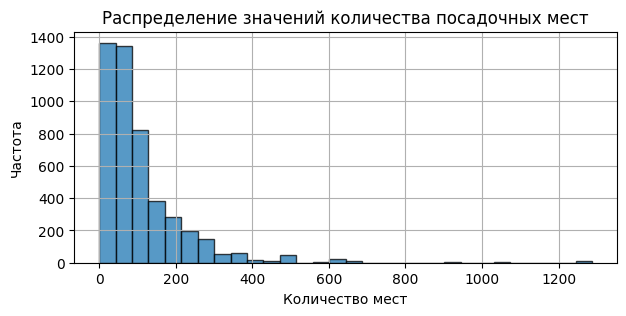

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas
df_final['seats'].plot(
    kind='hist',
    bins=30,
    alpha=0.75,
    edgecolor='black',
    rot=0)

# Настраиваем оформление графика
plt.title('Распределение значений количества посадочных мест')
plt.xlabel('Количество мест')
plt.ylabel('Частота')

# Отобразим сетку
plt.grid()

# Выводим график
plt.show()

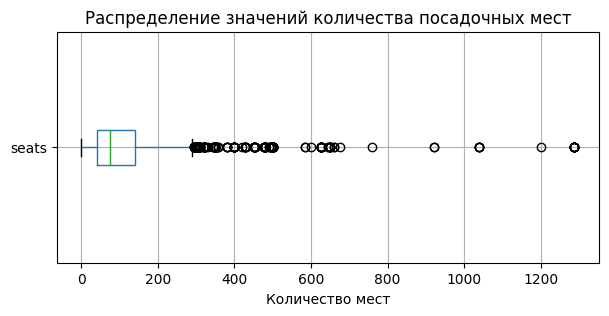

In [32]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим диаграмму размаха значений в столбце seats
df_final.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений количества посадочных мест')
plt.xlabel('Количество мест')

# Выводим график
plt.show()

Гистограмма показывает правоасимметричное распределение значений, где большинство значений сосредоточено в левой части и имеется длинный правый "хвост". Это указывает на присутствие высоких значений, которые оттягивают распределение вправо. Среднее значение превышает медиану — это также подтверждает наличие положительных выбросов, которые оказывают влияние на центральные показатели. Большинство значений сосредоточено около нуля. Это может говорить о том, что низкие значения часто встречаются в данных, а редкие высокие значения формируют правосторонний хвост. Высокие значения можно отнести к выбросам.

Проверим статистические показатели в группировке по категориям заведений.

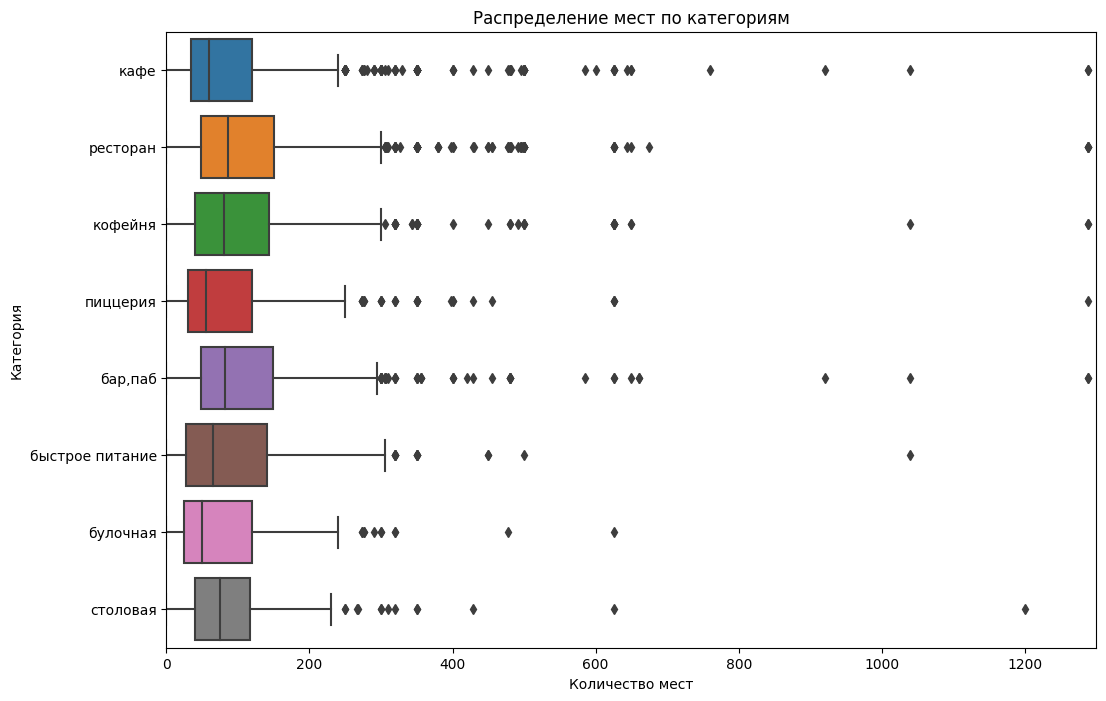

In [33]:
# Распределение значений по категориям
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_final, x='seats', y='category')
plt.xlim(0, 1300)
plt.title('Распределение мест по категориям')
plt.xlabel('Количество мест')
plt.ylabel('Категория')

plt.show()

Можно сделать предположение, что выбросы связаны с заведениями в спортивно-концертных комплексах, конгресс-холах или фуд-кортами.

In [34]:
# Выводим статистическую сводку по количеству посадочных мест для категорий заведений
df_final.groupby('category')['seats'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",467.0,124.477516,145.162277,0.0,48.0,82.0,148.5,1288.0
булочная,148.0,89.385132,97.685844,0.0,25.0,50.0,120.0,625.0
быстрое питание,349.0,98.891121,106.611740,0.0,28.0,65.0,140.0,1040.0
кафе,1217.0,97.365654,117.922462,0.0,35.0,60.0,120.0,1288.0
кофейня,751.0,111.199730,127.837776,0.0,40.0,80.0,144.0,1288.0
пиццерия,427.0,94.496490,112.282707,0.0,30.0,55.0,120.0,1288.0
ресторан,1269.0,121.892044,123.792213,0.0,48.0,86.0,150.0,1288.0
столовая,164.0,99.750000,122.951454,0.0,40.0,75.5,117.0,1200.0


Можем увидеть, что в каждой категории среднее значение превышает медианное. У пяти категорий совпадают максимальные значения. Сложно сказать является ли это аномалией. Так как выбросы искажают среднее значение, наиболее типичным значением следует принять медианное. Построим столбчатую диаграмму распределения количества посадочных мест по категориям.

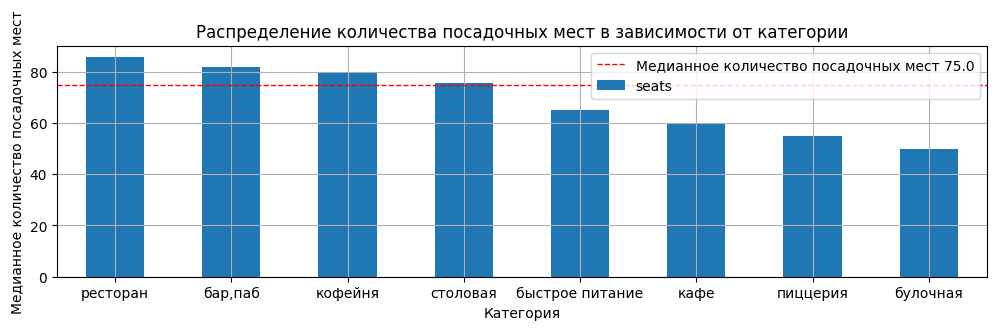

In [35]:
# Строим график столбчатой диаграммы
grouped = df_final.groupby('category')['seats'].median().sort_values(ascending=False)
grouped.plot(kind='bar',
               title=f'Распределение количества посадочных мест в зависимости от категории',
               legend=True,
               ylabel='Медианное количество посадочных мест',
               xlabel='Категория',
               rot=0,
               figsize=(12, 3))

# Рассчитываем медианное количество посадочных мест
median_seats = df['seats'].median()

# Наносим на график линию со средним количеством посадочных мест
plt.axhline(median_seats, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Медианное количество посадочных мест {round(median_seats,4)}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

Диаграмма показывает как распределяются категории по количеству посадочных мест. В ресторанах, кофейнях и барах посадочных мест обычно больше, чем в среднем по всем категориям заведений. Скорее всего объясняется это тем, что эти категории заведений расчитанны на длительное пребывание посетителей. При запуске нового заведения стоит учитывать этот фактор.

#### Анализ рейтинга заведений

Исследуем значения столбца `rating`, которое содержит рейтинг заведения по оценкам пользователей в Яндекс Картах. Выведем средний рейтинг для каждой категории заведений

In [36]:
# Выводим сводную статистику по столбцу rating
df_final['rating'].describe().reset_index()

,index,rating
0,count,8402.000000
1,mean,4.230016
2,std,0.470320
3,min,1.000000
4,25%,4.100000
5,50%,4.300000
6,75%,4.400000
7,max,5.000000


In [37]:
# Выводим сводную статистику рейтингов всех категорий
df_final.groupby('category')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124284,0.566001,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


Чтобы увидеть как сильно различаются усреднённые рейтинги для разных типов общепита, построим столбчатую диаграмму

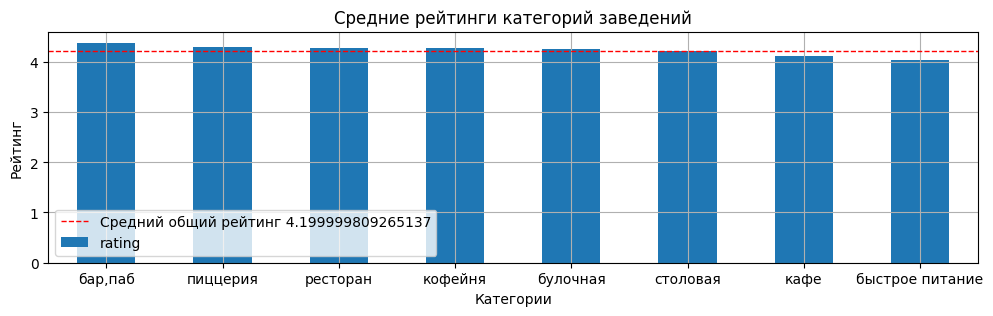

In [38]:
# Строим график столбчатой диаграммы
categories_mean = df_final.groupby('category')['rating'].mean().sort_values(ascending=False)
categories_mean.plot(kind='bar',
                     title='Средние рейтинги категорий заведений',
                     legend='True',
                     xlabel='Категории',
                     ylabel='Рейтинг',
                     rot=0,
                     figsize=(12, 3))

# Рассчитываем средний рейтинг по всем категориям
mean_rating = df_final['rating'].mean()

# Наносим на график линию общего среднего рейтинга
plt.axhline(mean_rating,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Средний общий рейтинг {round(mean_rating, 1)}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

На визуализации видно, что все категории имеют средний рейтинг больше 4 баллов. Также можно увидеть, что в категориях "быстрое питание" и "кафе" средний рейтинг ниже общего рейтинга. А самый высокий средний рейтинг наблюдается в категории "бар,паб".

Категория заведения влияет на ожидания клиента. В барах и ресторанах люди более снисходительны к деталям при хорошей атмосфере, в то время как в столовых любой сбой в сервисе сразу ведет к снижению оценки.

#### Корреляции рейтинга заведений с другими параметрами

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Рассчитаем коэффициенты корреляции phi_k и построим её визуализацию.

In [39]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df_final[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()

# Выводим результаты
print('\nКорреляционная матрица с коэффициентом phi_k:')
print(correlation_matrix.sort_values(by='rating', ascending=False))

interval columns not set, guessing: ['rating', 'chain', 'seats']

Корреляционная матрица с коэффициентом phi_k:
            rating  category  district     chain     seats     price   is_24_7
rating    1.000000  0.198739  0.189453  0.118857  0.000000  0.262056  0.161010
price     0.262056  0.566933  0.202787  0.218211  0.088146  1.000000  0.084183
category  0.198739  1.000000  0.174584  0.266000  0.048923  0.566933  0.244815
district  0.189453  0.174584  1.000000  0.064473  0.352440  0.202787  0.076357
is_24_7   0.161010  0.244815  0.076357  0.043488  0.043193  0.084183  1.000000
chain     0.118857  0.266000  0.064473  1.000000  0.056523  0.218211  0.043488
seats     0.000000  0.048923  0.352440  0.056523  1.000000  0.088146  0.043193


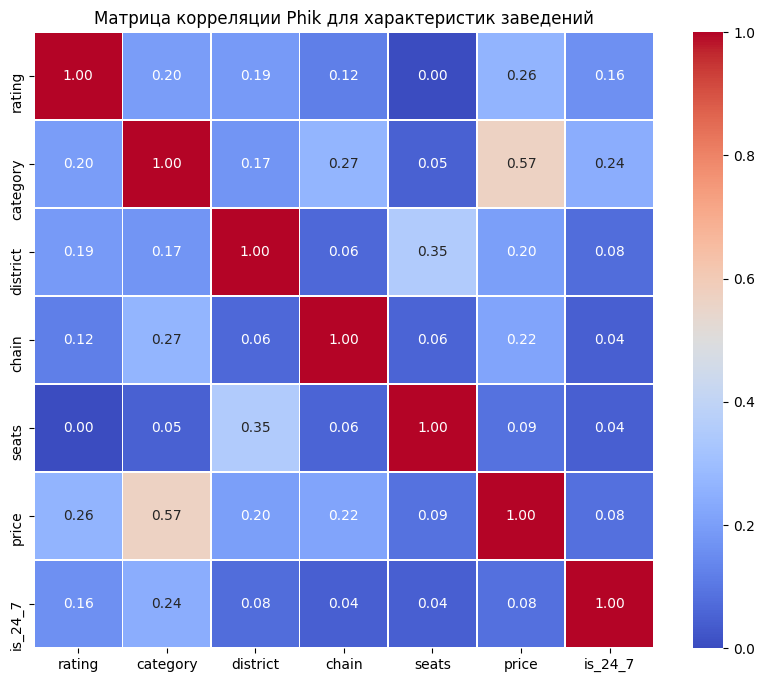

In [40]:
# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Матрица корреляции Phik для характеристик заведений')
plt.show()

Наибольшей корреляцией с рейтингом заведений имеют столбец `price` (0.26), `category` (0.2) и `district` (0.19). Также имеется слабая корреляция со столбцами `is_24_7` (0.16) и `chain` (0.12). Для наглядности визуализируем результат корреляции с помощью тепловой карты.

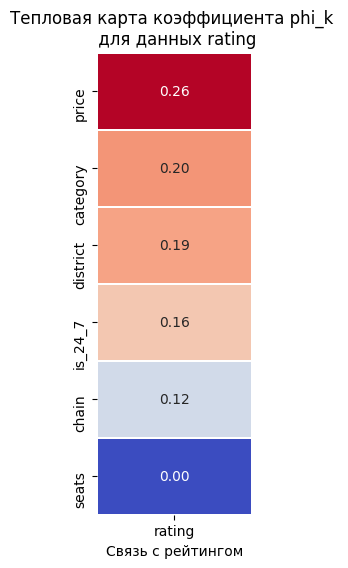

In [41]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции рейтинга с другими признаками клиента
rating_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(rating_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False)

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Связь с рейтингом')

# Выводим график
plt.show()

Самую сильную связь показывают столбцы `rating` и `price`. Проведем расчет значения среднего рейтинга для разных ценовых категорий

In [42]:
# Выводим средний рейтинг всех ценовых категорий
df_final.groupby('price')['rating'].mean().sort_values(ascending=False).reset_index()

,price,rating
0,высокие,4.436611
1,выше среднего,4.386348
2,средние,4.297874
3,низкие,4.173077


Заметна связь: чем выше ценовая категория, тем выше средний рейтинг заведения.

Проверим связь между `rating` и `price` и построим столбчатую диаграмму

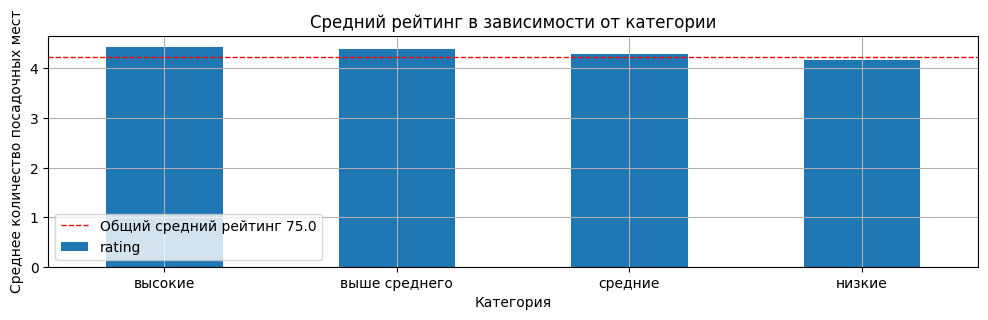

In [43]:
# Строим график столбчатой диаграммы
grouped = df_final.groupby('price')['rating'].mean().sort_values(ascending=False)
grouped.plot(kind='bar',
               title=f'Средний рейтинг в зависимости от категории',
               legend=True,
               ylabel='Среднее количество посадочных мест',
               xlabel='Категория',
               rot=0,
               figsize=(12, 3))

# Рассчитываем общий средний рейтинг
mean_rating = df_final['rating'].mean()

# Наносим на график линию со средним количеством посадочных мест
plt.axhline(mean_rating,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Общий средний рейтинг {round(median_seats,4)}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

По результатам анализа корреляции можно сделать вывод, что заведения из высокой ценовой категории имеют самый высокий средний рейтинг, а у заведений из низкой ценовой категории средний рейтинг самый низкий.

Можно сделать вывод, что люди склонны ставить более высокие баллы заведениям с высоким чеком, так как там лучше уровень сервиса и прочие характеристики.

#### Анализ сетевых заведений

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Под популярностью понимается количество заведений этой сети в регионе.

In [44]:
# Отфильтруем датафрейм и оставим данные только сетевых заведений
chain_df = df_final[df_final['chain'] == 1]

# Сгруппируем данные по названиям заведений и категориям
top_chains = chain_df.groupby(['name', 'category']).agg({'id': 'count', 'rating': 'mean'})

# Отсортируем данные по количеству и отберем 15 самых крупных сетей
top_chains = top_chains.rename(columns={'id': 'count', 'rating': 'mean_rating'}).sort_values(by='count', ascending=False).head(15).reset_index()
top_chains

,name,category,count,mean_rating
0,шоколадница,кофейня,119,4.178151
1,домино'с пицца,пиццерия,76,4.169737
2,додо пицца,пиццерия,74,4.286487
3,one price coffee,кофейня,71,4.064789
4,яндекс лавка,ресторан,69,3.872464
5,cofix,кофейня,65,4.075385
6,prime,ресторан,49,4.114285
7,кофепорт,кофейня,42,4.147619
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
9,теремок,ресторан,36,4.105556


Построим визуализацию среднего рейтинга топ-15 сетевых заведений

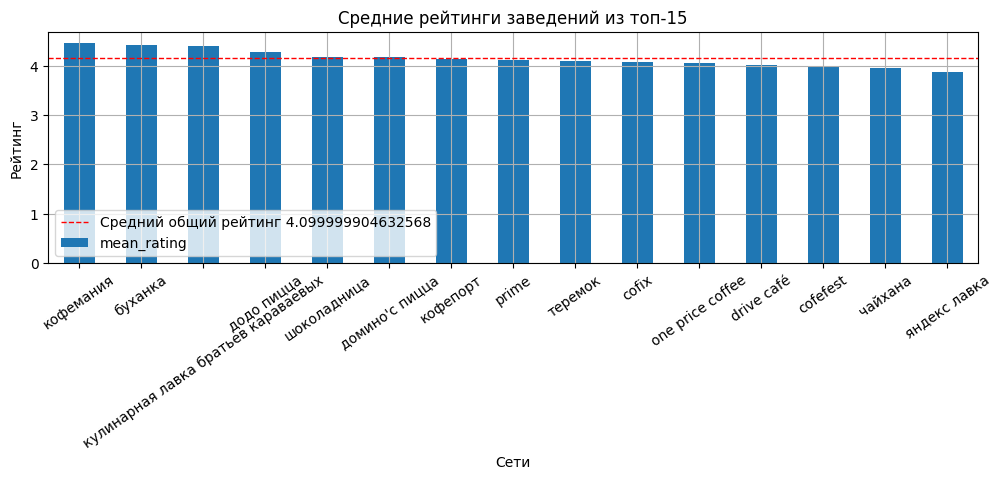

In [45]:
# Строим график столбчатой диаграммы
top_rating = top_chains.sort_values(by='mean_rating', ascending=False)
top_rating.plot(kind='bar',
                x='name',
                y='mean_rating',
                title='Средние рейтинги заведений из топ-15',
                legend='True',
                xlabel='Сети',
                ylabel='Рейтинг',
                rot=35,
                figsize=(12, 3))

# Рассчитываем средний рейтинг по сетям
mean_rating = top_rating['mean_rating'].mean()

# Наносим на график линию общего среднего рейтинга
plt.axhline(mean_rating,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Средний общий рейтинг {round(mean_rating, 1)}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

Визуализируем получившийся результат в виде линейчатой диаграммы

Text(0, 0.5, 'Название сети')

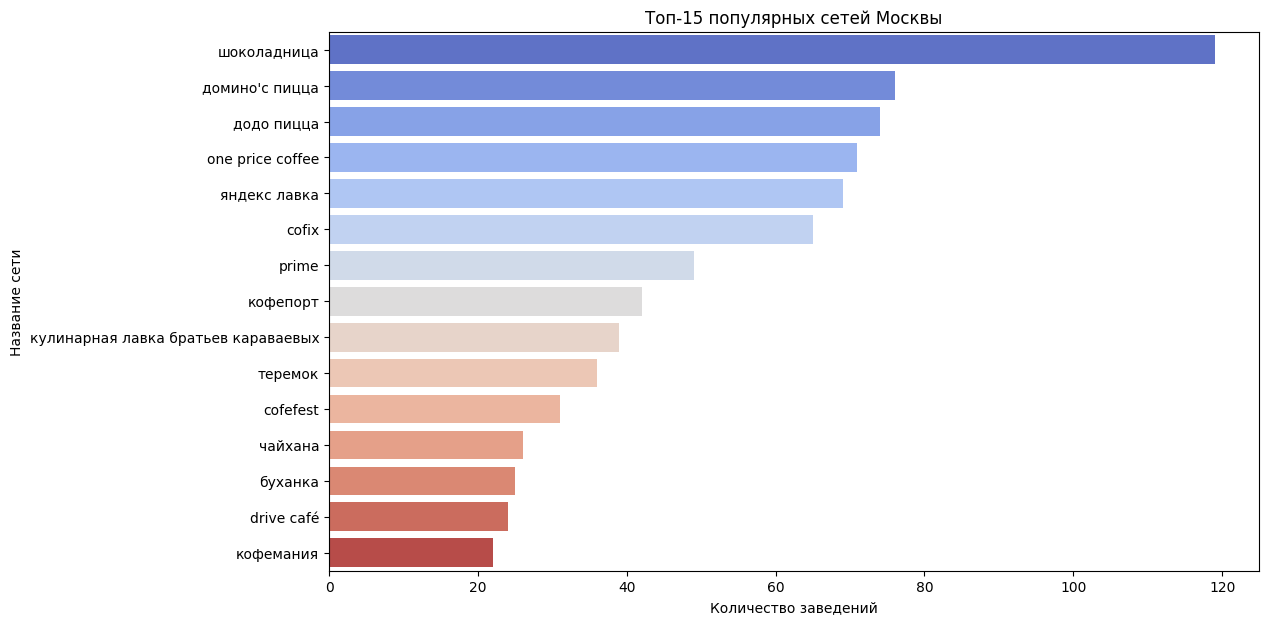

In [46]:
# Создаем контейнер графика
plt.figure(figsize=(12, 7))

# Строим диаграмму
sns.barplot(data=top_chains,
            x='count',
            y='name',
            palette='coolwarm')
plt.title('Топ-15 популярных сетей Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')

Самой популярной сетью является сеть кофеен "Шоколадница" (119 заведений). Второе и третье места занимают пиццерии "Домино'с Пицца" (76 заведений) и "Додо Пицца" (74 заведения).

Топ-15 сетей состоит в основном из заведений с небольшой площадью. Такая особенность позволяет сетям проще открывать новые заведения. Среди категорий преобладает категория "кофейня".

#### Анализ среднего чека заведений

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в центральном административном округе и других.

In [47]:
# Выводим статистические показатели данных по среднему чеку заведений
df_final['middle_avg_bill'].describe().reset_index()

,index,middle_avg_bill
0,count,3149.000000
1,mean,958.053650
2,std,1009.732849
3,min,0.000000
4,25%,375.000000
5,50%,750.000000
6,75%,1250.000000
7,max,35000.000000


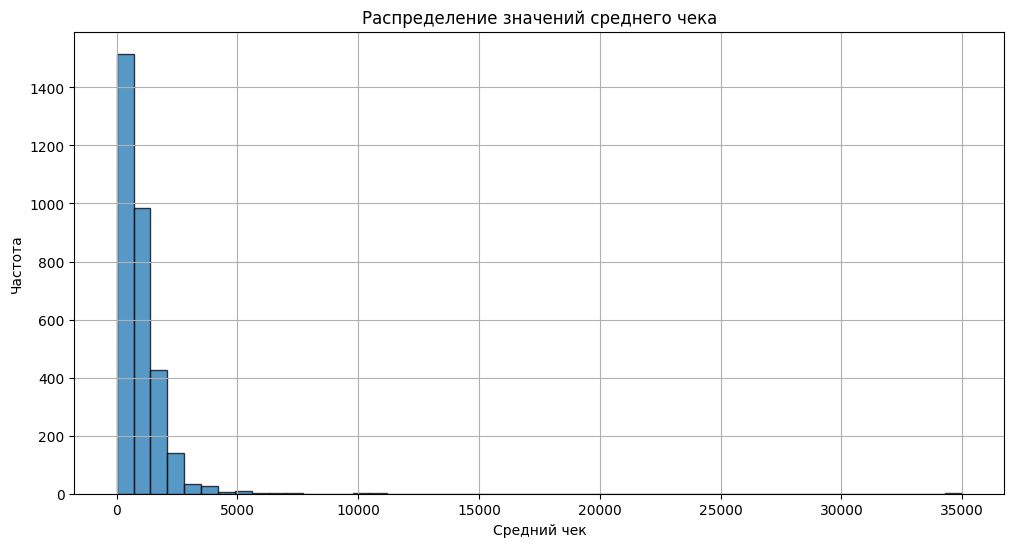

In [48]:
# Визуализируем анализ среднего чека заведений гистограммой
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим гистограмму
df_final['middle_avg_bill'].plot(
    kind='hist',
    bins=50,
    alpha=0.75,
    edgecolor='black',
    rot=0)

# Настраиваем оформление графика
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')

# Отобразим сетку
plt.grid()

# Выводим график
plt.show()

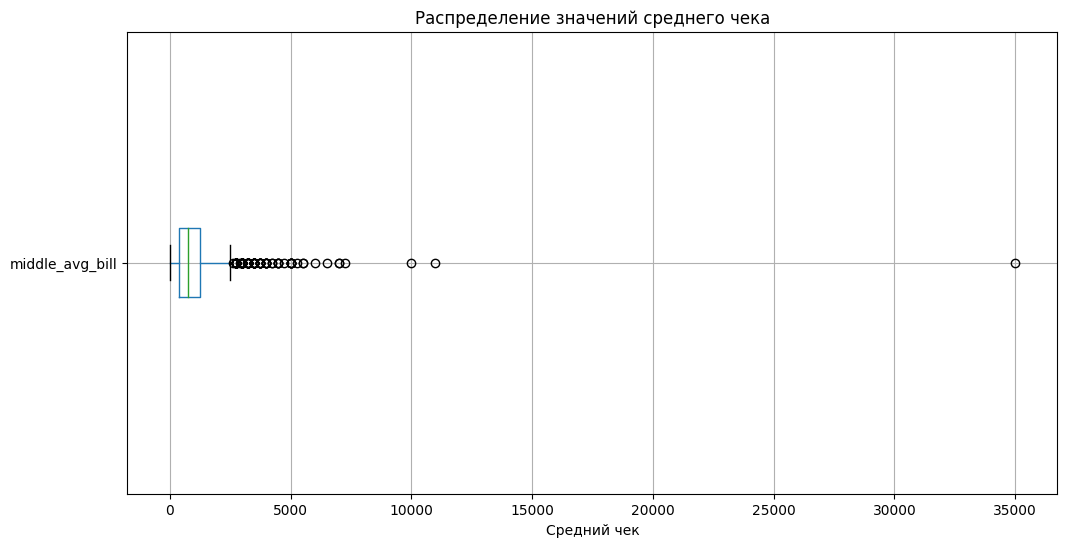

In [49]:
# Визуализируем анализ среднего чека заведений диаграммой размаха
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим диаграмму размаха значений среднего чека
df_final.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')

# Выводим график
plt.show()

Гистограмма распределения имеет правоасимметричное распределение значений, где большинство значений сосредоточено в левой части и имеется длинный правый "хвост". Это указывает на присутствие высоких значений, которые оттягивают распределение вправо. Среднее значение превышает медиану — это также подтверждает наличие положительных выбросов, которые оказывают влияние на центральные показатели. Большинство значений сосредоточено в диапазоне 375 - 1250 руб. Это может говорить о том, что низкие значения часто встречаются в данных, а редкие высокие значения формируют правосторонний хвост. Наблюдаются высокие значения, сосредоточенные на диаграмме размаха правее от линии Q3. Можно предположить, что такие значения характерны для категорий ресторанов и баров, которым свойственны высокие значения средних чеков. К выбросам можно отнести значения среднего чека больше 10000 руб.

In [50]:
# Выводим средний и медианный чек в группировке по району
grouped_bill = df_final.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).reset_index()
grouped_bill

,district,median,mean
0,Восточный административный округ,575.0,820.626953
1,Западный административный округ,1000.0,1053.225464
2,Северный административный округ,650.0,927.959656
3,Северо-Восточный административный округ,500.0,716.611267
4,Северо-Западный административный округ,700.0,822.222900
5,Центральный административный округ,1000.0,1191.057495
6,Юго-Восточный административный округ,450.0,654.097961
7,Юго-Западный административный округ,600.0,792.561707
8,Южный административный округ,500.0,834.398071


В центральном административном округе самые высокие средний и медианный чеки.

Проанализируем цены во всех округах.

In [51]:
# Выводим статистические показатели цен для всех районов
for i in df_final['district'].unique():
    print(f'\nСтатистические показатели столбца middle_avg_bill по району {i}:')
    print(df_final.loc[df_final['district'] == i]['middle_avg_bill'].describe())


Статистические показатели столбца middle_avg_bill по району Северный административный округ:
count      322.000000
mean       927.959656
std        912.609192
min        130.000000
25%        350.000000
50%        650.000000
75%       1250.000000
max      11000.000000
Name: middle_avg_bill, dtype: float64

Статистические показатели столбца middle_avg_bill по району Северо-Восточный административный округ:
count     301.000000
mean      716.611267
std       591.232117
min        50.000000
25%       325.000000
50%       500.000000
75%       950.000000
max      4500.000000
Name: middle_avg_bill, dtype: float64

Статистические показатели столбца middle_avg_bill по району Северо-Западный административный округ:
count     157.000000
mean      822.222900
std       595.055237
min       120.000000
25%       340.000000
50%       700.000000
75%      1100.000000
max      2900.000000
Name: middle_avg_bill, dtype: float64

Статистические показатели столбца middle_avg_bill по району Западный админис

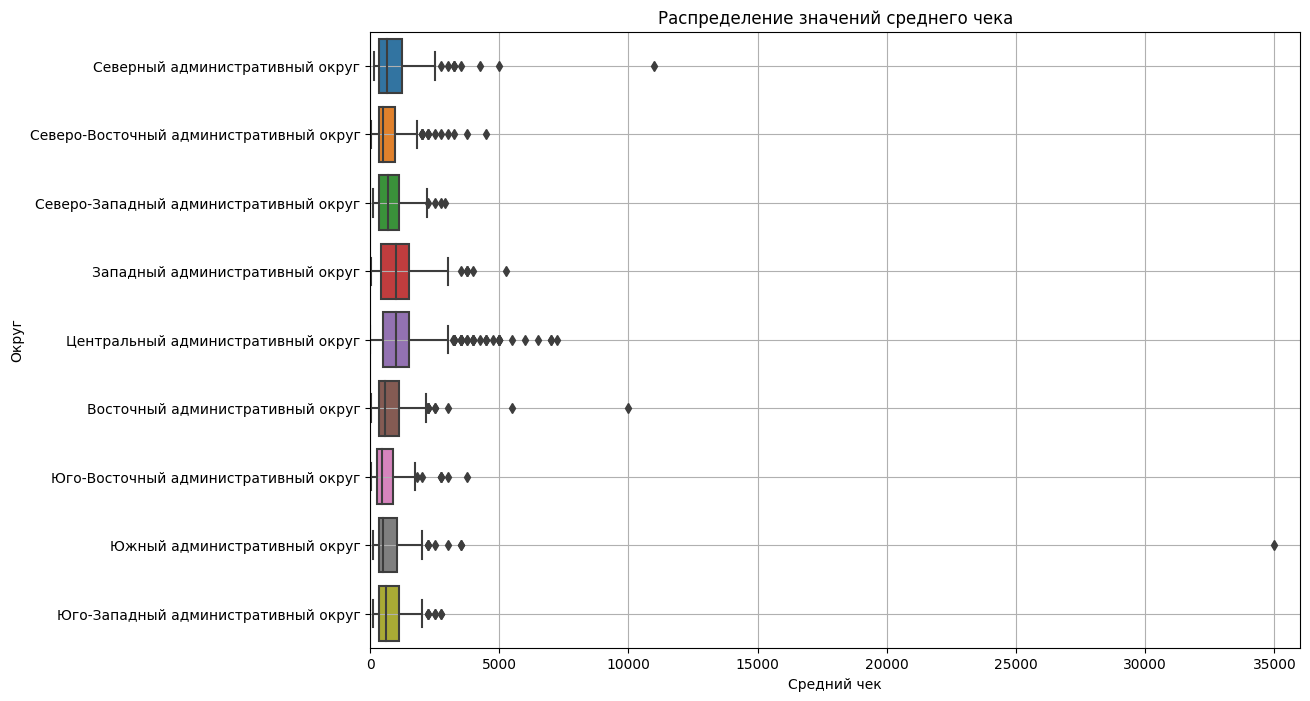

In [52]:
# Распределение значений среднего чека по округам
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_final, x='middle_avg_bill', y='district')
plt.xlim(0, 36000)
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Округ')

plt.grid()
plt.show()

Касательно центрального административного округа можно предположить, что данные о средних чеках имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако значение стандартного отклонения довольно высокое — `920.01`, и при среднем `1191.06` это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.
Дополнительно проверим это и построим гистограмму распределения значений для столбца со средним чеком.

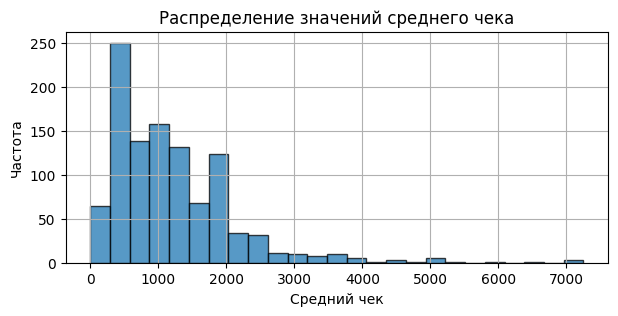

In [53]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_final.loc[df['district'] == 'Центральный административный округ']['middle_avg_bill'].plot(
                kind='hist',
                bins=25,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Гистограмма показывает правоасимметричное распределение значений, где большинство значений сосредоточено в левой части и имеется длинный правый "хвост". Это указывает на присутствие высоких значений, которые оттягивают распределение вправо. Среднее значение превышает медиану — это также подтверждает наличие положительных выбросов, которые оказывают влияние на центральные показатели. Большинство значений сосредоточено в диапазоне 400 - 2000, а редкие высокие значения формируют правосторонний хвост.

Проверим существует ли корреляция между столбцами `district` и `middle_avg_bill`. Рассчитаем коэффициент корреляции phi_k.

In [54]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df_final[['district', 'middle_avg_bill']].phik_matrix()

# Выводим результаты
print('Корреляционная матрица с коэффициентом phi_k:')
print(correlation_matrix)

interval columns not set, guessing: ['middle_avg_bill']
Корреляционная матрица с коэффициентом phi_k:
                 district  middle_avg_bill
district         1.000000         0.056558
middle_avg_bill  0.056558         1.000000


Коэффициент корреляции 0.06 говорит о наличии слабой связи между столбцами `district` и `middle_avg_bill`.

<Figure size 1200x600 with 0 Axes>

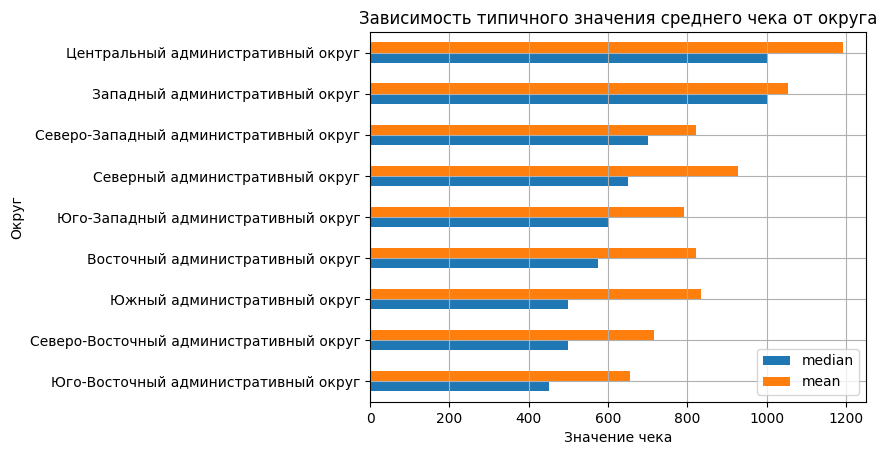

In [55]:
grouped_bill = df_final.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).sort_values(by='median')

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим линейчатаю диаграмму
grouped_bill.plot(kind='barh',
                  rot=0,
                  grid=True)
plt.title('Зависимость типичного значения среднего чека от округа')
plt.xlabel('Значение чека')
plt.ylabel('Округ')
plt.show()

Центральный и западный административные округа обладают самыми высокими средними и медианными чеками в сравнении с другими округами. На это могла повлиять стоимость аренды помещения в этих округах, которая может быть выше, чем в других. В Северо-Западном и Юго-западном округах минимальные выбросы по среднему чеку. У Южного и Северного административных округов наблюдается большой разрыв между средним и медианным чеком из-за экстремальных значений. Самые низкие значения среднего и медианного чека наблюдаются у Юго-Восточного и Северо-Восточного округов. Возможно это связано с меньшим уровнем дохода жителей и с инфраструктурными особенностями этих округов.

<a class='anchor' id="link4"></a>
## 4. Итоговые выводы

В ходе исследования проанализировали данные 8406 заведений общепита в Москве. Данные включали информацию о местоположении, рейтинге, категориях, принадлежности к сети, ценовых категориях и средних ценах заведений. Акцент исследования был на том, чтобы найти взаимосвязи между различными факторами и параметрами заведений. Среди них: количество посадочных мест, рейтинг, категория заведения, район, часы работы, принадлежность к сети, ценовая категория, средний чек.

В ходе предобработки данных:
1. Объединены атафреймы `info_df` и `price_df`. Объединенный датасет содержал 8406 строк и 13 столбцов. После преобразований датасет`df_final` содержит 8402 и 14 столбцов. Датасет содержит данные о заведениях общепита Москвы. Датасет составлен на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках.
2. Типы данных в датафрейме не требовали изменений. В столбцах с числовыми типами данных `rating`,`middle_avg_bill`,`middle_coffee_cup`,`seats` и `chain` была понижена разрядность
3. Изучены пропуски в данных. 
    - Столбец `hours` - 536 пропусков - 6% данных.
    - Столбец `seats` - 3611 пропусков - 43% данных. 
    - Столбец `price` - 743 пропуска - 18% данных
    - Столбец `avg_bill` - 242 пропуска - 6% данных.
    - Столбец `middle_avg_bill` - 909 пропусков - 22% данных.
    - Столбец `middle_coffee_cup` - 3523 пропуска - 87% данных.
    
    Учитывая, что данные могли быть добавлены пользователями или найдены в общедоступных источниках, они носят исключительно справочный характер, пропуски оставили без изменений.
4. Датасет не содержит явных дубликатов. Удалено 4 неявных дубликата содержащих дублирующие значения `name` и `address`.
5. В датасет добавлен столбец `is_24_7`, который содержит бинарный признак является ли график работы заведения ежедневным и круглосуточным.
6. В итоговом виде датафрейм `df_final` содержит 8402 и 14 столбцов и готов к дальнейшему анализу.

#### Категории заведений
Анализ категорий заведений показал, что самыми популярными категориями являются кафе, ресторан и кофейня.

#### Распределение заведений по районам
Центральный административный округ - лидер по количеству заведений. Категория "ресторан" находится на первом месте по количеству заведений в центральном административном округе.

#### Соотношение сетевых и несетевых заведений
Картина в целом показывает, что доля несетевых заведений больше 60%. Доля сетевых заведений преобладает в категориях "пиццерия", "кофейня" и "булочная". В остальных категориях преобладают несетевые заведения.

#### Количество посадочных мест
В ресторанах, кофейнях и барах посадочных мест обычно больше, чем в среднем по всем категориям заведений.

#### Рейтинг заведений
Все категории имеют средний рейтинг больше 4 баллов. В категориях "быстрое питание" и "кафе" средний рейтинг ниже общего рейтинга. А самый высокий средний рейтинг наблюдается в категории "бар,паб".

#### Корреляции рейтинга заведений с другими параметрами
Заведения из высоких ценовых категорий имеют самый высокий средний рейтинг, а у заведений из низкой ценовой категории средний рейтинг самый низкий.

#### Лидеры среди сетевых заведений
Самой популярной сетью является сеть кофеен "Шоколадница" (119 заведений). Второе и третье места занимают пиццерии "Домино'с Пицца" (76 заведений) и "Додо Пицца" (74 заведения).

#### Вариации среднего чека
В Центральном и Западном административных округах самые высокие средние чеки. Существует слабая корреляция между районом и средним чеком.

#### Рекомендации
Для открытия заведения общепита можно выделить следующие рекомендации:
- Категории кафе, ресторан, кофейня и бар являются лидерами по количеству. Для запуска нового заведения стоит рассмотреть эти категории общепита.
- Центральный и Западный административные округа следует рассмотреть для получения высокого показателя среднего чека
- Рекомендуемое количество посадочных мест 80. Примерно такое количество наблюдается у заведений в категориях ресторан, кофейня и бар. Для получения хороших отзывов посетителей и более высокого рейтинга рекомендуется установить ежедневный и круглосуточный режим работы.
- С учетом полученной информации стоит рассмотреть открытие бара в Центральном или Западном административном округе. Выбор округов обусловлен более высоким уровнем дохода потенциальных посетителей в сравнении с другими округами. Выбор категории бара поможет избежать конкуренции в других более широко представленных категориях.